In [ ]:
import os
import re
from tqdm import tqdm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
%matplotlib inline

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!nvidia-smi

Sun Mar  8 03:38:32 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   54C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
if torch.cuda.is_available():
    device = torch.device("cuda")
    print(f'There are {torch.cuda.device_count()} GPU(s) available.')
    print('Device name:', torch.cuda.get_device_name(0))
else:
    print('No GPU available, using the CPU instead.')
    device = torch.device("cpu")

There are 1 GPU(s) available.
Device name: Tesla T4


In [ ]:
def load_original_dataset(fold=1, mode='train', percentage=None):
    df = pd.read_csv(f'/content/drive/MyDrive/spin-off/final_dataset/fold_{fold}/10-fold_original_{percentage}/algocite_utilize_dataset_{mode}_fold_{fold}.csv')
    df['CLEAN_CITATION_CONTEXT'] = df['CLEAN_CITATION_CONTEXT'].str.replace(r"=-=[\S\s]+-=-", "<cite>", regex=True)
    X, y = df['CLEAN_CITATION_CONTEXT'].values, df['USAGE_LABELS'].values
    return X, y

In [ ]:
fold = 3
percentage = '50_percent'

X_train, y_train = load_original_dataset(fold=fold, mode='train', percentage=percentage)
X_test, y_test = load_original_dataset(fold=fold, mode='test', percentage=percentage)
X_val, y_val = load_original_dataset(fold=fold, mode='val', percentage=percentage)

In [ ]:
from collections import Counter

# Before
print(Counter(y_train))

Counter({'MENTION': 1785, 'USE': 618, 'NOTALGO': 567, 'EXTEND': 212})


In [ ]:
from transformers import BertTokenizer

citation_tokens = ['<cite>']
tokenizer = BertTokenizer.from_pretrained("allenai/scibert_scivocab_uncased", do_lower_case=True)
tokenizer.add_tokens(citation_tokens)

def preprocessing_for_bert(data):

    input_ids = []
    attention_masks = []
    token_type_ids = []

    for sent in data:
        encoded_sent = tokenizer(
            text=sent,
            add_special_tokens=True,
            max_length=MAX_LEN,
            truncation=True,
            padding='max_length',
            #return_tensors='pt',
            return_attention_mask=True,
            return_token_type_ids=True
        )

        input_ids.append(encoded_sent.get('input_ids'))
        attention_masks.append(encoded_sent.get('attention_mask'))
        token_type_ids.append(encoded_sent.get('token_type_ids'))

    input_ids = torch.tensor(input_ids)
    attention_masks = torch.tensor(attention_masks)
    token_type_ids = torch.tensor(token_type_ids)

    return input_ids, attention_masks, token_type_ids

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


vocab.txt: 0.00B [00:00, ?B/s]

In [ ]:
MAX_LEN = 256

token_ids = list(preprocessing_for_bert([X_train[0]])[0].squeeze().numpy())
print('Original: ', X_train[0])
print('Token IDs: ', token_ids)

print('Tokenizing data...')
train_inputs, train_masks, train_token_type = preprocessing_for_bert(X_train)
val_inputs, val_masks, val_token_type = preprocessing_for_bert(X_val)

Original:  ch and its even more elaborate successors have been responsible for the fastest known algorithms for almost all classes of finite groups, including the symmetric groups 29 and their wreath products . these are among the classes of groups for which o g log c g fourier transform algorithms are known. other examples include the supersolvable groups 3 , while the algorithms for finite matrix gro
Token IDs:  [np.int64(102), np.int64(249), np.int64(137), np.int64(633), np.int64(1390), np.int64(475), np.int64(19384), np.int64(26691), np.int64(30113), np.int64(360), np.int64(528), np.int64(4312), np.int64(168), np.int64(111), np.int64(22675), np.int64(1721), np.int64(2617), np.int64(168), np.int64(3343), np.int64(355), np.int64(3899), np.int64(131), np.int64(3427), np.int64(1302), np.int64(422), np.int64(1471), np.int64(111), np.int64(6433), np.int64(1302), np.int64(2583), np.int64(137), np.int64(547), np.int64(1800), np.int64(11901), np.int64(266), np.int64(2800), np.int64(205), np

In [ ]:
encoding = dict()
for idx, class_name in enumerate(np.unique(y_train)):
    encoding[class_name] = idx

y_train_encoded = [encoding[key] for key in y_train]
y_val_encoded = [encoding[key] for key in y_val]
y_test_encoded = [encoding[key] for key in y_test]

In [ ]:
from collections import Counter

count = Counter(y_train)
class_count = np.array([count.get(list(encoding)[idx]) for idx in range(len(np.unique(y_train)))])
weight = 1./class_count
print(weight)

[0.00471698 0.00056022 0.00176367 0.00161812]


In [ ]:
samples_weight = np.array([weight[t] for t in y_train_encoded])
samples_weight = torch.from_numpy(samples_weight)
print(samples_weight)

tensor([0.0006, 0.0006, 0.0006,  ..., 0.0016, 0.0016, 0.0018],
       dtype=torch.float64)


In [ ]:
from torch.utils.data import TensorDataset, DataLoader, RandomSampler, SequentialSampler, WeightedRandomSampler

train_labels = torch.tensor(y_train_encoded)
val_labels = torch.tensor(y_val_encoded)

# batch size = 16, 32
batch_size = 32

train_data = TensorDataset(train_inputs, train_masks, train_token_type, train_labels)
train_sampler = RandomSampler(train_data)
# train_sampler = WeightedRandomSampler(samples_weight, len(samples_weight))
train_dataloader = DataLoader(train_data, sampler=train_sampler, batch_size=batch_size)

val_data = TensorDataset(val_inputs, val_masks, val_token_type, val_labels)
val_sampler = SequentialSampler(val_data)
val_dataloader = DataLoader(val_data, sampler=val_sampler, batch_size=batch_size)

In [ ]:
print(next(iter(train_dataloader)))

[tensor([[  102,  3274,   928,  ...,     0,     0,     0],
        [  102,   106, 13185,  ...,     0,     0,     0],
        [  102,   111,  2460,  ...,     0,     0,     0],
        ...,
        [  102,   112, 16735,  ...,     0,     0,     0],
        [  102,   112,   111,  ...,     0,     0,     0],
        [  102,  3546,   923,  ...,     0,     0,     0]]), tensor([[1, 1, 1,  ..., 0, 0, 0],
        [1, 1, 1,  ..., 0, 0, 0],
        [1, 1, 1,  ..., 0, 0, 0],
        ...,
        [1, 1, 1,  ..., 0, 0, 0],
        [1, 1, 1,  ..., 0, 0, 0],
        [1, 1, 1,  ..., 0, 0, 0]]), tensor([[0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0],
        ...,
        [0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0]]), tensor([0, 1, 1, 1, 3, 2, 3, 3, 2, 1, 1, 1, 2, 1, 2, 1, 3, 1, 1, 1, 1, 1, 1, 3,
        3, 1, 2, 1, 2, 1, 1, 1])]


In [ ]:
print(len(train_dataloader))

100


In [ ]:
import torch
import torch.nn as nn
from transformers import BertForSequenceClassification
from torch.optim import AdamW
from transformers import get_linear_schedule_with_warmup

def initialize_model(epochs=10):

    bert_classifier = BertForSequenceClassification.from_pretrained("allenai/scibert_scivocab_uncased",
                                                                    num_labels=4,
                                                                    output_attentions=False,
                                                                    output_hidden_states=False)
    bert_classifier.resize_token_embeddings(len(tokenizer))
    bert_classifier.to(device)

    optimizer = torch.optim.AdamW([
            {'params': bert_classifier.bert.parameters(), 'lr': 1e-5},
            {'params': bert_classifier.classifier.parameters(), 'lr': 1e-5}
        ],eps=1e-8, betas=(0.9, 0.999), weight_decay=1e-2)

#     optimizer = AdamW(bert_classifier.parameters(),
#                       lr=1e-5,
#                       eps=1e-8,
#                 )

    total_steps = len(train_dataloader) * epochs

    warmup_steps_percentage = 0
    scheduler = get_linear_schedule_with_warmup(optimizer,
                                                num_warmup_steps=(warmup_steps_percentage/100)*total_steps,
                                                num_training_steps=total_steps
                )

    return bert_classifier, optimizer, scheduler

In [ ]:
import os
os.makedirs('/content/drive/MyDrive/models2', exist_ok=True)
os.makedirs('/content/drive/MyDrive/cls_results2', exist_ok=True)

In [ ]:
import random
import time
import torch.nn.functional as F
from sklearn.metrics import f1_score, precision_score, recall_score
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.utils import class_weight

# from sadice import SelfAdjDiceLoss
# class_weights = class_weight.compute_class_weight(class_weight='balanced', classes=np.unique(y_train_encoded),y=y_train_encoded)
# class_weights = torch.tensor(class_weights, dtype=torch.float, device=device)
# loss_fn = nn.CrossEntropyLoss(weight=class_weights, reduction='mean')

loss_fn = nn.CrossEntropyLoss()

# Specify loss function
# weights = torch.tensor([4, 1], dtype=torch.float, device=device)
# loss_fn = nn.CrossEntropyLoss(weight=weights)
# loss_fn = SelfAdjDiceLoss()
# loss_fn = nn.BCELoss()
training_stats = list()
val_results = list()
test_results = list()
model_path = f'/content/drive/MyDrive/models2/Fine-Tuning_SciBERT_AlgoCite_UTILIZE_Context_CostSensitive_Fold_{fold}.h5'

def set_seed(seed_value=42):
    """Set seed for reproducibility.
    """
    random.seed(seed_value)
    np.random.seed(seed_value)
    torch.manual_seed(seed_value)
    torch.cuda.manual_seed_all(seed_value)

def train(model, train_dataloader, val_dataloader=None, test_dataloader=None, epochs=10, evaluation=False):
    """Train the BertClassifier model.
    """
    # Start training loop
    print("Start training...\n")
    best_accuracy = 0

    for epoch_i in range(epochs):
        # =======================================
        #               Training
        # =======================================
        # Print the header of the result table
        print(f"{'Epoch':^7} | {'Batch':^7} | {'Train Loss':^12} | {'Val Loss':^10} | {'Val Acc':^9} | {'Elapsed':^9}")
        print("-"*70)

        # Measure the elapsed time of each epoch
        t0_epoch, t0_batch = time.time(), time.time()

        # Reset tracking variables at the beginning of each epoch
        total_loss, batch_loss, batch_counts = 0, 0, 0

        # Put the model into the training mode
        model.train()

        # For each batch of training data...
        for step, batch in enumerate(train_dataloader):
            batch_counts +=1
            # Load batch to GPU
            b_input_ids, b_attn_mask, b_token_type_ids, b_labels = tuple(t.to(device) for t in batch)

            # Zero out any previously calculated gradients
            model.zero_grad()

            # Perform a forward pass. This will return logits.
            outputs = model(b_input_ids, b_attn_mask, b_token_type_ids)
            logits = outputs.logits

            # Compute loss and accumulate the loss values
            loss = loss_fn(logits, b_labels)
            batch_loss += loss.item()
            total_loss += loss.item()

            # Perform a backward pass to calculate gradients
            loss.backward()

            # Clip the norm of the gradients to 1.0 to prevent "exploding gradients"
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

            # Update parameters and the learning rate
            optimizer.step()
            scheduler.step()

            # Print the loss values and time elapsed for every 20 batches
            if (step % 20 == 0 and step != 0) or (step == len(train_dataloader) - 1):
                # Calculate time elapsed for 20 batches
                time_elapsed = time.time() - t0_batch

                # Print training results
                print(f"{epoch_i + 1:^7} | {step:^7} | {batch_loss / batch_counts:^12.6f} | {'-':^10} | {'-':^9} | {time_elapsed:^9.2f}")

                # Reset batch tracking variables
                batch_loss, batch_counts = 0, 0
                t0_batch = time.time()

        # Calculate the average loss over the entire training data
        avg_train_loss = total_loss / len(train_dataloader)

        print("-"*70)
        # =======================================
        #               Evaluation
        # =======================================
        if evaluation == True:
            # After the completion of each training epoch, measure the model's performance
            # on our validation set.
            val_loss, val_accuracy = evaluate(model, val_dataloader)

            # Print performance over the entire training data
            time_elapsed = time.time() - t0_epoch

            print(f"{epoch_i + 1:^7} | {'-':^7} | {avg_train_loss:^12.6f} | {val_loss:^10.6f} | {val_accuracy:^9.2f} | {time_elapsed:^9.2f}")
            print("-"*70)

            training_stats.append(
                {
                    'Epoch': epoch_i + 1,
                    'Training_Loss': avg_train_loss,
                    'Valid_Loss': val_loss,
                    'Valid_Accuracy': val_accuracy,
                    'Time_Elapsed': time_elapsed,
                }
            )

            if val_accuracy > best_accuracy:
                torch.save(model.state_dict(), model_path)
                best_accuracy = val_accuracy

        print("\n")

    print("Training complete!")


def evaluate(model, val_dataloader):
    """After the completion of each training epoch, measure the model's performance
    on our validation set.
    """
    # Put the model into the evaluation mode. The dropout layers are disabled during
    # the test time.
    model.eval()

    # Tracking variables
    val_accuracy = []
    val_loss = []

    # For each batch in our validation set...
    for batch in val_dataloader:
        # Load batch to GPU
        b_input_ids, b_attn_mask, b_token_type_ids, b_labels = tuple(t.to(device) for t in batch)

        # Compute logits
        with torch.no_grad():
            outputs = model(b_input_ids, b_attn_mask, b_token_type_ids)
            logits = outputs.logits

        # Compute loss
        #print(logits)
        #print(b_labels)
        loss = loss_fn(logits, b_labels)
        val_loss.append(loss.item())

        # Get the predictions
        preds = torch.argmax(logits, dim=1).flatten()

        # Calculate the accuracy rate
        accuracy = (preds == b_labels).cpu().numpy().mean() * 100
        val_accuracy.append(accuracy)

    # Compute the average accuracy and loss over the validation set.
    val_loss = np.mean(val_loss)
    val_accuracy = np.mean(val_accuracy)

    return val_loss, val_accuracy

In [ ]:
set_seed(42)    # Set seed for reproducibility
bert_classifier, optimizer, scheduler = initialize_model(epochs=4)
train(bert_classifier, train_dataloader, val_dataloader, epochs=4, evaluation=True)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: allenai/scibert_scivocab_uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were ne

Start training...

 Epoch  |  Batch  |  Train Loss  |  Val Loss  |  Val Acc  |  Elapsed 
----------------------------------------------------------------------
   1    |   20    |   1.195152   |     -      |     -     |   31.58  
   1    |   40    |   1.133357   |     -      |     -     |   29.65  
   1    |   60    |   1.045122   |     -      |     -     |   29.15  
   1    |   80    |   0.944711   |     -      |     -     |   30.10  
   1    |   99    |   0.852778   |     -      |     -     |   28.04  
----------------------------------------------------------------------
   1    |    -    |   1.037648   |  0.832479  |   66.64   |  161.06  
----------------------------------------------------------------------


 Epoch  |  Batch  |  Train Loss  |  Val Loss  |  Val Acc  |  Elapsed 
----------------------------------------------------------------------
   2    |   20    |   0.800375   |     -      |     -     |   30.14  
   2    |   40    |   0.707736   |     -      |     -     |   29.

In [ ]:
df_stats = pd.DataFrame(training_stats)
df_stats.set_index('Epoch', inplace=True)
df_stats

,Training_Loss,Valid_Loss,Valid_Accuracy,Time_Elapsed
Epoch,,,,
1,1.037648,0.832479,66.643519,161.057986
2,0.713950,0.660076,77.064815,159.909734
3,0.584739,0.618399,76.768519,159.799954
4,0.518701,0.607814,77.893519,159.618759


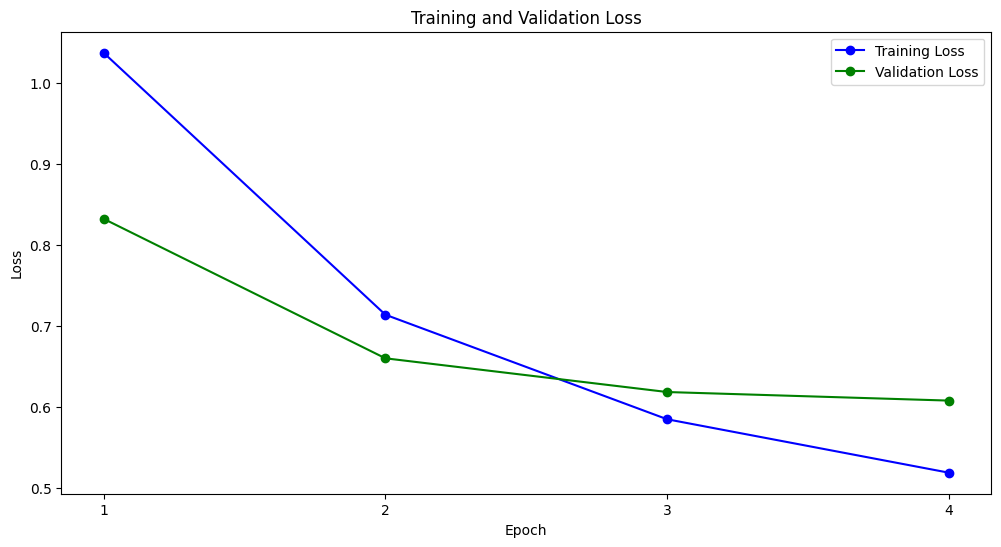

In [ ]:
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (12, 6)

plt.plot(df_stats['Training_Loss'], 'b-o', label='Training Loss')
plt.plot(df_stats['Valid_Loss'], 'g-o', label='Validation Loss')

plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.xticks(df_stats.index)

plt.show()

In [ ]:
# Run `preprocessing_for_bert` on the test set
print('Tokenizing data...')
test_inputs, test_masks, test_token_type = preprocessing_for_bert(X_test)

# Create the DataLoader for our test set
test_dataset = TensorDataset(test_inputs, test_masks, test_token_type)
test_sampler = SequentialSampler(test_dataset)
test_dataloader = DataLoader(test_dataset, sampler=test_sampler, batch_size=batch_size)

Tokenizing data...


In [ ]:
from sklearn.metrics import accuracy_score, roc_curve, auc

def evaluate_roc(probs, y_true):
    """
    - Print AUC and accuracy on the test set
    - Plot ROC
    @params    probs (np.array): an array of predicted probabilities with shape (len(y_true), 2)
    @params    y_true (np.array): an array of the true values with shape (len(y_true),)
    """
    preds = probs[:, 1]
    fpr, tpr, threshold = roc_curve(y_true, preds)
    roc_auc = auc(fpr, tpr)
    print(f'AUC: {roc_auc:.4f}')

    # Get accuracy over the test set
    y_pred = np.where(preds >= 0.5, 1, 0)
    accuracy = accuracy_score(y_true, y_pred)
    print(f'Accuracy: {accuracy*100:.2f}%')

    # Plot ROC AUC
    plt.title('Receiver Operating Characteristic')
    plt.plot(fpr, tpr, 'b', label = 'AUC = %0.2f' % roc_auc)
    plt.legend(loc = 'lower right')
    plt.plot([0, 1], [0, 1],'r--')
    plt.xlim([0, 1])
    plt.ylim([0, 1])
    plt.ylabel('True Positive Rate')
    plt.xlabel('False Positive Rate')
    plt.show()

In [ ]:
import torch.nn.functional as F

def bert_predict(model, test_dataloader):
    """Perform a forward pass on the trained BERT model to predict probabilities
    on the test set.
    """
    # Put the model into the evaluation mode. The dropout layers are disabled during
    # the test time.
    model.eval()

    all_logits = []

    # For each batch in our test set...
    for batch in test_dataloader:
        # Load batch to GPU
        b_input_ids, b_attn_mask, b_token_type_ids = tuple(t.to(device) for t in batch)[:3]

        # Compute logits
        with torch.no_grad():
            outputs = model(b_input_ids, b_attn_mask, b_token_type_ids)
            logits = outputs.logits
        all_logits.append(logits)

    # Concatenate logits from each batch
    all_logits = torch.cat(all_logits, dim=0)

    # Apply softmax to calculate probabilities
    probs = F.softmax(all_logits, dim=1).cpu().numpy()

    return probs

In [ ]:
best_model_path = f'/content/drive/MyDrive/models2/Fine-Tuning_SciBERT_AlgoCite_UTILIZE_Context_CostSensitive_Fold_{fold}.h5'
best_model = BertForSequenceClassification.from_pretrained("allenai/scibert_scivocab_uncased",
                                                           num_labels=4,
                                                           output_attentions=False,
                                                           output_hidden_states=False)
best_model.resize_token_embeddings(len(tokenizer))
best_model.load_state_dict(torch.load(best_model_path))
best_model.to(device)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: allenai/scibert_scivocab_uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were ne

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(31091, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

In [ ]:
probs = bert_predict(best_model, test_dataloader)

In [ ]:
# Get predictions from the probabilities
# threshold = 0.5
# preds = np.where(probs[:, 1] > 0.5, 1, 0)
preds = np.argmax(probs, axis=1)

In [ ]:
from sklearn.metrics import f1_score, precision_score, recall_score
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

usage_class_names = ['MENTION', 'NOTALGO', 'USE', 'EXTEND']
utilize_class_names = ['NOTUTILIZE', 'UTILIZE']

y_test_encoded = [encoding[key] for key in y_test]
accuracy = accuracy_score(y_test_encoded, preds)
precision = precision_score(y_test_encoded, preds, average='macro')
recall = recall_score(y_test_encoded, preds, average='macro')
f1 = f1_score(y_test_encoded, preds, average='macro')

print("Accuracy: %.5f%%" % (accuracy*100))
print("Precision Score: %.5f" % (precision*100))
print("Recall Score: %.5f" % (recall*100))
print("F1 Score: %.5f" % (f1*100))

print(classification_report(y_test_encoded, preds, target_names=usage_class_names, digits=3))

Accuracy: 78.73303%
Precision Score: 73.33193
Recall Score: 71.25092
F1 Score: 70.63135
              precision    recall  f1-score   support

     MENTION      0.567     0.630     0.596        27
     NOTALGO      0.831     0.895     0.862       247
         USE      0.809     0.437     0.567        87
      EXTEND      0.727     0.889     0.800        81

    accuracy                          0.787       442
   macro avg      0.733     0.713     0.706       442
weighted avg      0.791     0.787     0.776       442



In [ ]:
# evaluate_roc(probs, y_test_encoded)

In [ ]:
from sklearn.metrics import confusion_matrix

print(confusion_matrix(y_test_encoded, preds))

[[ 17   1   2   7]
 [  4 221   7  15]
 [  9  35  38   5]
 [  0   9   0  72]]


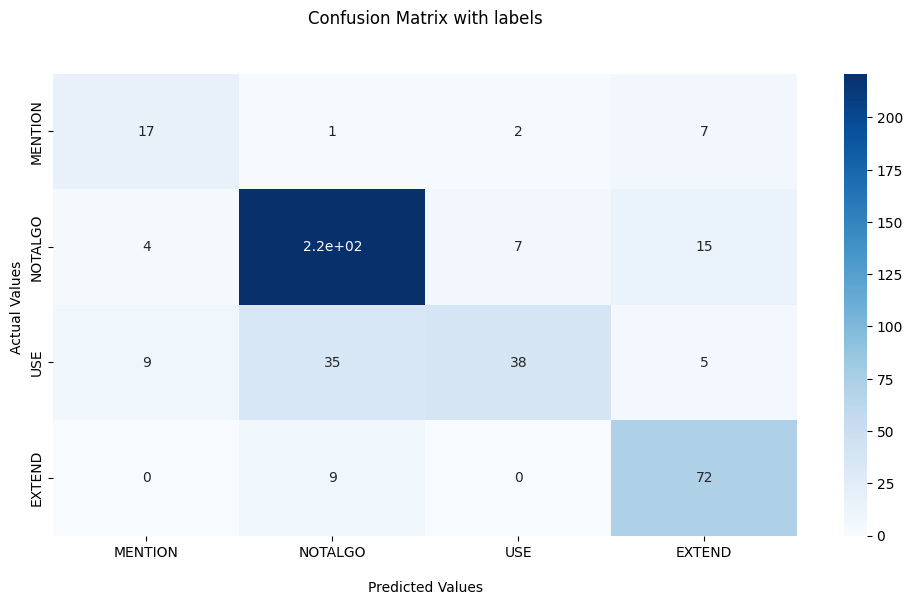

In [ ]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

cf_matrix = confusion_matrix(y_test_encoded, preds)

ax = sns.heatmap(cf_matrix, annot=True, cmap='Blues')

ax.set_title('Confusion Matrix with labels\n\n');
ax.set_xlabel('\nPredicted Values')
ax.set_ylabel('Actual Values ');

## Ticket labels - List must be in alphabetical order
ax.xaxis.set_ticklabels(usage_class_names)
ax.yaxis.set_ticklabels(usage_class_names)

## Display the visualization of the Confusion Matrix.
plt.show()

In [ ]:
inv_encoding = {v: k for k, v in encoding.items()}
pred_label = [inv_encoding[key] for key in preds]

In [ ]:
df_test = pd.DataFrame({'CITATIONS_CONTEXTS': X_test, 'USAGE_LABELS': y_test, 'PRED_LABELS': pred_label})
df_test

,CITATIONS_CONTEXTS,USAGE_LABELS,PRED_LABELS
0,and range query are common types of queries op...,MENTION,MENTION
1,1 and guo 12 as a bridge between direct and in...,MENTION,MENTION
2,"e, we perform the same set of experiments for ...",MENTION,MENTION
3,n estimate of the fraction of the collision-fr...,USE,USE
4,les in an optimal solution coincide with the s...,MENTION,MENTION
...,...,...,...
437,of so-called patches each separatingstwo diffe...,EXTEND,EXTEND
438,viewed in references 13 and 27). a series of i...,NOTALGO,NOTALGO
439,ffective the lossy allocator was in comparison...,MENTION,USE
440,ted bands. selection ofsrst few bands from eac...,EXTEND,USE


In [ ]:
df_test.to_csv(
    f'/content/drive/MyDrive/cls_results2/Fine-Tuning_SciBERT_original_USAGE_{percentage}_Fold_{fold}.csv',
    index=False
)